# Speech Emotion Recognition

This notebook implements a **Speech Emotion Recognition (SER)** pipeline using **emotion2vec_plus_large** as a feature extractor followed by a custom **MLP classifier**.

The pipeline is evaluated both globally and per-dataset to identify strengths and weaknesses across different data sources.

### Datasets Used

| Dataset  | Samples  | Gender          | Available Emotions |
|----------|----------|-----------------|---------------------|
| RAVDESS  | ~1,440   | Male + Female   | 7                   |
| CREMA    | ~7,442   | Male + Female   | 6 (no surprise)     |
| TESS     | ~2,800   | Female only     | 7                   |
| SAVEE    | ~480     | Male only       | 7                   |

Per-dataset evaluation allows us to pinpoint which datasets the model struggles with and guide targeted improvements.

## 1. Installation

Install the required dependencies. [FunASR](https://github.com/modelscope/FunASR) is the official framework from Alibaba used to load the emotion2vec model.

In [1]:
!pip install -q funasr modelscope torch torchaudio librosa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 32.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 45.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.0/812.0 kB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 113.2 MB/s eta 0:00:00


## 2. Imports

We import libraries for:
- **Data handling**: pandas, numpy, pathlib
- **Audio processing**: librosa
- **Visualization**: matplotlib, seaborn
- **ML utilities**: scikit-learn (metrics, splitting, class weights)
- **Deep learning**: PyTorch (model definition, training, mixed-precision)

A global random seed (`SEED = 42`) is set across all libraries for reproducibility.

In [2]:
import pandas as pd
import numpy as np
import os, sys, random, gc
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import librosa
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
sns.set_theme(style='whitegrid')

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB


## 3. Mount Google Drive & Define Dataset Paths

This notebook runs on Google Colab. We mount Google Drive to access the audio datasets stored there.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define the root directories for each of the four datasets. These paths point to the audio files stored on Google Drive.

- **TESS**: Toronto Emotional Speech Set
- **RAVDESS**: Ryerson Audio-Visual Database of Emotional Speech and Song
- **SAVEE**: Surrey Audio-Visual Expressed Emotion
- **CREMA-D**: Crowd-sourced Emotional Multimodal Actors Dataset

In [4]:
TESS    = '/content/drive/MyDrive/datasets/tess/TESS Toronto emotional speech set data/'
RAVDESS = '/content/drive/MyDrive/datasets/ravdess/audio_speech_actors_01-24/'
SAVEE   = '/content/drive/MyDrive/datasets/savee/ALL/'
CREMA   = '/content/drive/MyDrive/datasets/cremad/AudioWAV/'

## 4. Load & Merge Datasets

Each dataset has its own file naming convention for encoding metadata (emotion, gender, speaker ID). The cells below parse each dataset separately, extracting labels in the format `{gender}_{emotion}` (e.g., `female_happy`, `male_angry`).

### 4.1 RAVDESS

RAVDESS filenames encode metadata in dash-separated fields. Field 3 (index 2) is the emotion code, and field 7 (index 6) is the actor ID (even = female, odd = male).

In [5]:
dir_list = sorted(os.listdir(RAVDESS))
emotion, gender, path, speaker = [], [], [], []
for i in dir_list:
    if i == 'audio_speech_actors_01-24':
        break
    for f in os.listdir(RAVDESS + i):
        part = f.split('.')[0].split('-')
        emotion.append(int(part[2]))
        gender.append('female' if int(part[6]) % 2 == 0 else 'male')
        speaker.append(f'RAVDESS_{part[6]}')
        path.append(RAVDESS + i + '/' + f)
Ravdess_df = pd.DataFrame(emotion).replace(
    {1:'neutral',2:'neutral',3:'happy',4:'sad',5:'angry',6:'fear',7:'disgust',8:'surprise'})
Ravdess_df = pd.concat([pd.DataFrame(gender), Ravdess_df], axis=1)
Ravdess_df.columns = ['gender','emotion']
Ravdess_df['labels']  = Ravdess_df.gender + '_' + Ravdess_df.emotion
Ravdess_df['source']  = 'RAVDESS'
Ravdess_df['speaker'] = speaker
Ravdess_df = pd.concat([Ravdess_df, pd.DataFrame(path, columns=['path'])], axis=1)
Ravdess_df = Ravdess_df.drop(['gender','emotion'], axis=1)

### 4.2 CREMA-D

CREMA-D filenames use underscores: `{actor_id}_{sentence}_{emotion}_{intensity}.wav`. Gender is determined by matching the actor ID against a known list of female speakers.

In [6]:
dir_list = sorted(os.listdir(CREMA))
female_ids = [1002,1003,1004,1006,1007,1008,1009,1010,1012,1013,1018,1020,1021,1024,
              1025,1028,1029,1030,1037,1043,1046,1047,1049,1052,1053,1054,1055,1056,
              1058,1060,1061,1063,1072,1073,1074,1075,1076,1078,1079,1082,1084,1089,1091]
emo_map_crema = {'SAD':'sad','ANG':'angry','DIS':'disgust','FEA':'fear','HAP':'happy','NEU':'neutral'}
gender, emotion, path, speaker = [], [], [], []
for i in dir_list:
    part = i.split('_')
    g = 'female' if int(part[0]) in female_ids else 'male'
    emotion.append(f'{g}_{emo_map_crema.get(part[2], "Unknown")}')
    speaker.append(f'CREMA_{part[0]}')
    path.append(CREMA + i)
CREMA_df = pd.DataFrame(emotion, columns=['labels'])
CREMA_df['source']  = 'CREMA'
CREMA_df['speaker'] = speaker
CREMA_df = pd.concat([CREMA_df, pd.DataFrame(path, columns=['path'])], axis=1)

### 4.3 TESS

TESS contains recordings from two female speakers (OAF and YAF). The folder names encode the speaker and emotion, which are mapped to the standard label format.

In [7]:
emo_map_tess = {
    'oaf_angry':'female_angry','yaf_angry':'female_angry',
    'oaf_disgust':'female_disgust','yaf_disgust':'female_disgust',
    'oaf_fear':'female_fear','yaf_fear':'female_fear',
    'oaf_happy':'female_happy','yaf_happy':'female_happy',
    'oaf_neutral':'female_neutral','yaf_neutral':'female_neutral',
    'oaf_pleasant_surprise':'female_surprise','yaf_pleasant_surprised':'female_surprise',
    'oaf_sad':'female_sad','yaf_sad':'female_sad',
}
path, emotion, speaker = [], [], []
for i in os.listdir(TESS):
    spk = 'TESS_OAF' if 'oaf' in i.lower() else 'TESS_YAF'
    for f in os.listdir(TESS + i):
        emotion.append(emo_map_tess.get(i.lower(), 'Unknown'))
        speaker.append(spk)
        path.append(TESS + i + '/' + f)
TESS_df = pd.DataFrame(emotion, columns=['labels'])
TESS_df['source']  = 'TESS'
TESS_df['speaker'] = speaker
TESS_df = pd.concat([TESS_df, pd.DataFrame(path, columns=['path'])], axis=1)

### 4.4 SAVEE

SAVEE contains recordings from 4 male speakers (DC, JE, JK, KL). Emotion is encoded in the last characters of the filename.

In [8]:
emo_map_savee = {'_a':'male_angry','_d':'male_disgust','_f':'male_fear',
                 '_h':'male_happy','_n':'male_neutral','sa':'male_sad','su':'male_surprise'}
spk_map_savee = {'DC':'SAVEE_DC','JE':'SAVEE_JE','JK':'SAVEE_JK','KL':'SAVEE_KL'}
emotion, path, speaker = [], [], []
for i in os.listdir(SAVEE):
    emotion.append(emo_map_savee.get(i[-8:-6], 'Unknown'))
    speaker.append(spk_map_savee.get(i[:2], f'SAVEE_{i[:2]}'))
    path.append(SAVEE + i)
SAVEE_df = pd.DataFrame(emotion, columns=['labels'])
SAVEE_df['source']  = 'SAVEE'
SAVEE_df['speaker'] = speaker
SAVEE_df = pd.concat([SAVEE_df, pd.DataFrame(path, columns=['path'])], axis=1)

### 4.5 Merge All Datasets

Concatenate the four DataFrames into a single unified dataset. Rows with unknown or erroneous labels are filtered out. The merged dataset is saved to CSV for reference.

In [9]:
data_path = pd.concat([Ravdess_df, CREMA_df, TESS_df, SAVEE_df], axis=0)
data_path = data_path[~data_path.labels.str.contains('Unknown|error', case=False)]
data_path = data_path.reset_index(drop=True)
data_path.to_csv('new_data_path.csv', index=False)

print(f'Total: {len(data_path)} amostras')
print(f'Speakers únicos: {data_path.speaker.nunique()}')
print(f'Por dataset: {data_path.source.value_counts().to_dict()}')

Total: 12162 amostras
Speakers únicos: 121
Por dataset: {'CREMA': 7442, 'TESS': 2800, 'RAVDESS': 1440, 'SAVEE': 480}


## 5. Feature Extraction with emotion2vec_plus_large

[emotion2vec](https://github.com/ddlBoJack/emotion2vec) is a pre-trained speech emotion representation model. The `emotion2vec_plus_large` variant produces a **768-dimensional embedding** for each utterance, capturing emotion-relevant acoustic features.

We use these fixed embeddings as input to a downstream MLP classifier, rather than fine-tuning the entire model.

### 5.1 Load the emotion2vec Model

The model is loaded via the FunASR framework from ModelScope.

In [10]:
from funasr import AutoModel

emo2vec = AutoModel(
    model          = 'iic/emotion2vec_plus_large',
    model_revision = 'v2.0.5',
    device         = str(DEVICE),
)
print('emotion2vec_plus_large loaded!')

funasr version: 1.3.1.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
You are using the latest version of funasr-1.3.1


2026-03-23 13:26:13,218 - modelscope - INFO - Use user-specified model revision: v2.0.5
2026-03-23 13:26:14,050 - modelscope - INFO - Got 11 files, start to download ...


Processing 11 items:   0%|          | 0.00/11.0 [00:00<?, ?it/s]

2026-03-23 14:11:04,585 - modelscope - INFO - Download model 'iic/emotion2vec_plus_large' successfully.


Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.3.0.weight, /root/.cache/modelscope/hub/models

### 5.2 Extract or Load Cached Features

Feature extraction is expensive (~15-20 min for all samples). To avoid re-extraction, features are cached in `.npz` files. The code checks for existing cache files (v14 or v15 format) before extracting from scratch.

Each sample produces a 1024-dim embedding vector. The dataset source (`RAVDESS`, `CREMA`, etc.) is derived from the speaker ID prefix.

In [ ]:
NPZ_V14 = 'features_emotion2vec_v14.npz'
NPZ_V15 = 'features_emotion2vec_v15.npz'

def extract_emo2vec(path: str) -> np.ndarray:
    res = emo2vec.generate(
        path,
        granularity       = 'utterance',
        extract_embedding = True,
    )
    return res[0]['feats'].squeeze().astype(np.float32)


def derive_source(speaker_id: str) -> str:
    return speaker_id.split('_')[0]


if os.path.exists(NPZ_V15):
    print('Loading cached v15 features...')
    cached = np.load(NPZ_V15, allow_pickle=True)
    X_all   = cached['X']
    Y_all   = cached['Y']
    S_all   = cached['S']    # speaker IDs
    SRC_all = cached['SRC']  # dataset de origem
    print(f'Loaded: {X_all.shape}, labels={len(Y_all)}')

elif os.path.exists(NPZ_V14):
    print('Loading cached v14 features, deriving source...')
    cached  = np.load(NPZ_V14, allow_pickle=True)
    X_all   = cached['X']
    Y_all   = cached['Y']
    S_all   = cached['S']
    SRC_all = np.array([derive_source(s) for s in S_all])
    np.savez_compressed(NPZ_V15, X=X_all, Y=Y_all, S=S_all, SRC=SRC_all)
    print(f'Source derived and saved to {NPZ_V15}')
    print(f'Loaded: {X_all.shape} | Datasets: {np.unique(SRC_all, return_counts=True)}')

else:
    print('Extracting emotion2vec features for all samples...')

    X_all, Y_all, S_all, SRC_all = [], [], [], []
    n = len(data_path)
    errors = 0

    for idx, row in data_path.iterrows():
        if idx % 500 == 0:
            print(f'  {idx}/{n} ({idx/n*100:.1f}%)')
        try:
            feat = extract_emo2vec(row['path'])
            X_all.append(feat)
            Y_all.append(row['labels'])
            S_all.append(row['speaker'])
            SRC_all.append(row['source'])
        except Exception as e:
            errors += 1
            if errors <= 5:
                print(f'  Erro em {row["path"]}: {e}')

    X_all   = np.array(X_all, dtype=np.float32)
    Y_all   = np.array(Y_all)
    S_all   = np.array(S_all)
    SRC_all = np.array(SRC_all)

    np.savez_compressed(NPZ_V15, X=X_all, Y=Y_all, S=S_all, SRC=SRC_all)
    print(f'Saved: {NPZ_V15} | shape={X_all.shape} | errors={errors}')

Extraindo features emotion2vec para todas as amostras...
(primeira vez — leva ~15-20 min; salvo em NPZ para reuso)
  0/12162 (0.0%)


rtf_avg: 0.198: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


  500/12162 (4.1%)


rtf_avg: 0.209: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


  1000/12162 (8.2%)


...

  11500/12162 (94.6%)


rtf_avg: 0.292: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


  12000/12162 (98.7%)


rtf_avg: 0.206: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


Salvo: features_emotion2vec_v15.npz | shape=(12162, 1024) | erros=0


## 6. Train/Test Split & Normalization

The dataset is split into 80% training and 20% test using **stratified sampling** on the label column to preserve class distribution.

Labels are encoded as integer indices for both emotion (7 classes) and gender (2 classes). The dataset source is tracked for per-dataset evaluation later.

Features are normalized using **Z-score standardization** (zero mean, unit variance), fitted on the training set only.

In [12]:
ALL_EMOTIONS = sorted(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'])
ALL_GENDERS  = ['female', 'male']
DATASETS     = ['RAVDESS', 'CREMA', 'TESS', 'SAVEE']
EMO_TO_IDX   = {e: i for i, e in enumerate(ALL_EMOTIONS)}
GEN_TO_IDX   = {g: i for i, g in enumerate(ALL_GENDERS)}

def parse_label(lbl):
    parts = lbl.split('_')
    return EMO_TO_IDX[parts[1]], GEN_TO_IDX[parts[0]]

idx_all = np.arange(len(X_all))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=SEED,
    shuffle=True, stratify=Y_all
)

X_train, X_test = X_all[idx_train], X_all[idx_test]
Y_train, Y_test = Y_all[idx_train], Y_all[idx_test]
src_test = SRC_all[idx_test]
spk_test = S_all[idx_test]

train_emo = np.array([parse_label(l)[0] for l in Y_train])
train_gen = np.array([parse_label(l)[1] for l in Y_train])
test_emo  = np.array([parse_label(l)[0] for l in Y_test])
test_gen  = np.array([parse_label(l)[1] for l in Y_test])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('\nAmostras de teste por dataset:')
for ds in DATASETS:
    n = (src_test == ds).sum()
    print(f'  {ds:<10} {n:4d} amostras')

X_train: (9729, 1024) | X_test: (2433, 1024)

Amostras de teste por dataset:
  RAVDESS     276 amostras
  CREMA      1490 amostras
  TESS        569 amostras
  SAVEE        98 amostras


## 7. MLP Classifier

The classifier is a multi-layer perceptron (MLP) that takes the 768-dim emotion2vec embeddings as input and predicts both emotion and gender.

### 7.1 Architecture Definition

The model consists of:
- **AttentionSelfPool**: A feature-wise gating mechanism that learns which dimensions of the embedding are most discriminative for classification. It multiplies each feature by a learned sigmoid gate.
- **EmotionMLP**: The main classifier with:
  - Batch normalization on the input
  - Emotion head: `768 -> 512 -> 256 -> 128 -> 7` with GELU activations, batch norm, and dropout at each layer
  - Gender head: `768 -> 64 -> 2` (auxiliary task for regularization)

In [13]:
class AttentionSelfPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(dim, dim, bias=False)

    def forward(self, x):  # x: (B, D)
        return x * torch.sigmoid(self.w(x))


class EmotionMLP(nn.Module):
    def __init__(self, in_dim=768, num_emo=7, num_gen=2):
        super().__init__()
        self.gate = AttentionSelfPool(in_dim)
        self.bn0  = nn.BatchNorm1d(in_dim)

        self.emo_head = nn.Sequential(
            nn.Linear(in_dim, 512), nn.GELU(), nn.BatchNorm1d(512), nn.Dropout(0.4),
            nn.Linear(512, 256),   nn.GELU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),   nn.GELU(), nn.BatchNorm1d(128), nn.Dropout(0.2),
            nn.Linear(128, num_emo),
        )
        self.gen_head = nn.Sequential(
            nn.Linear(in_dim, 64), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(64, num_gen),
        )

    def forward(self, x):
        x = self.gate(x)
        x = self.bn0(x)
        return self.emo_head(x), self.gen_head(x)


in_dim = X_train.shape[1]
mlp    = EmotionMLP(in_dim=in_dim).to(DEVICE)
total  = sum(p.numel() for p in mlp.parameters())
print(f'MLP parameters: {total:,}')
print(f'Architecture: {in_dim} -> 512 -> 256 -> 128 -> 7')

MLP parâmetros: 1,808,073
Arquitetura: 1024 → 512 → 256 → 128 → 7


### 7.2 Data Loaders

Convert the numpy arrays to PyTorch tensors and create DataLoaders for batched training and evaluation.

In [16]:
BATCH_SIZE = 256

X_tr   = torch.tensor(X_train, dtype=torch.float32)
X_te   = torch.tensor(X_test,  dtype=torch.float32)
y_tr_e = torch.tensor(train_emo, dtype=torch.long)
y_te_e = torch.tensor(test_emo,  dtype=torch.long)
y_tr_g = torch.tensor(train_gen, dtype=torch.long)
y_te_g = torch.tensor(test_gen,  dtype=torch.long)

train_ds = TensorDataset(X_tr, y_tr_e, y_tr_g)
test_ds  = TensorDataset(X_te, y_te_e, y_te_g)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f'Train: {len(train_loader)} batches | Test: {len(test_loader)} batches')

Train: 38 batches | Test: 10 batches


## 8. Training

The training procedure uses the following strategy:

- **Loss**: Weighted cross-entropy for emotion (handles class imbalance) with label smoothing (0.05). Gender prediction is an auxiliary loss weighted at 0.1x.
- **Optimizer**: AdamW with weight decay (1e-3)
- **Scheduler**: OneCycleLR with cosine annealing for smooth learning rate warmup and decay
- **Mixed precision**: Automatic mixed precision (AMP) via GradScaler for faster training on GPU
- **Early stopping**: Training stops if validation accuracy doesn't improve for 30 consecutive epochs
- **Checkpointing**: The best model (by validation accuracy) is saved to disk

In [17]:
weights_np    = compute_class_weight('balanced', classes=np.arange(len(ALL_EMOTIONS)), y=train_emo)
emo_weights   = torch.tensor(weights_np, dtype=torch.float32).to(DEVICE)
emo_criterion = nn.CrossEntropyLoss(weight=emo_weights, label_smoothing=0.05)
gen_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

EPOCHS   = 300
PATIENCE = 30
LR       = 3e-4

optimizer = AdamW(mlp.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr           = LR,
    total_steps      = EPOCHS * len(train_loader),
    pct_start        = 0.1,
    anneal_strategy  = 'cos',
    div_factor       = 25.0,
    final_div_factor = 1e4,
)
amp_scaler = GradScaler()

CKPT_PATH        = 'best_emo2vec_mlp_v15.pt'
best_val_acc     = 0.0
patience_counter = 0
history          = {'train_acc': [], 'val_acc': [], 'loss': []}

for epoch in range(1, EPOCHS + 1):
    mlp.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, emo, gen in train_loader:
        x, emo, gen = x.to(DEVICE), emo.to(DEVICE), gen.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            eo, go = mlp(x)
            loss = emo_criterion(eo, emo) + 0.1 * gen_criterion(go, gen)
        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer)
        amp_scaler.update()
        scheduler.step()

        total_loss += loss.item()
        correct    += (eo.argmax(1) == emo).sum().item()
        total      += len(emo)

    mlp.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x, emo, _ in test_loader:
            x, emo = x.to(DEVICE), emo.to(DEVICE)
            with autocast():
                eo, _ = mlp(x)
            val_correct += (eo.argmax(1) == emo).sum().item()
            val_total   += len(emo)

    train_acc = correct / total
    val_acc   = val_correct / val_total
    avg_loss  = total_loss / len(train_loader)

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['loss'].append(avg_loss)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save({'epoch': epoch, 'model': mlp.state_dict(),
                    'amp_scaler': amp_scaler.state_dict(), 'val_acc': val_acc}, CKPT_PATH)
        marker = ' ✓'
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch <= 5 or marker:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | '
              f'Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping (epoch {epoch}, patience={PATIENCE})')
        break

print(f'\nBest accuracy: {best_val_acc*100:.2f}%')

Epoch   1/300 | Loss: 0.9424 | Train: 0.8473 | Val: 0.9005 ✓
Epoch   2/300 | Loss: 0.7506 | Train: 0.8883 | Val: 0.9014 ✓
Epoch   3/300 | Loss: 0.6813 | Train: 0.8965 | Val: 0.9055 ✓
Epoch   4/300 | Loss: 0.6401 | Train: 0.8985 | Val: 0.9055
Epoch   5/300 | Loss: 0.6224 | Train: 0.9022 | Val: 0.9083 ✓
Epoch   7/300 | Loss: 0.5959 | Train: 0.9053 | Val: 0.9100 ✓
Epoch   9/300 | Loss: 0.5910 | Train: 0.9024 | Val: 0.9104 ✓
Epoch  10/300 | Loss: 0.5885 | Train: 0.9038 | Val: 0.9096
Epoch  20/300 | Loss: 0.5728 | Train: 0.9043 | Val: 0.9059
Epoch  30/300 | Loss: 0.5602 | Train: 0.9075 | Val: 0.9067
Early stopping (epoch 39, patience=30)

Melhor acurácia: 91.04%


## 9. Global Evaluation

Load the best checkpoint and evaluate on the full test set. This provides overall accuracy for both emotion and gender classification, along with a per-class classification report.

### 9.1 Load Best Checkpoint & Run Inference

In [18]:
ckpt = torch.load(CKPT_PATH)
mlp.load_state_dict(ckpt['model'])
print(f"Checkpoint: epoch {ckpt['epoch']} | val_acc={ckpt['val_acc']:.4f}")

mlp.eval()
p_emo, t_emo, p_gen, t_gen = [], [], [], []
with torch.no_grad():
    for x, emo, gen in test_loader:
        x = x.to(DEVICE)
        with autocast():
            eo, go = mlp(x)
        p_emo.extend(eo.argmax(1).cpu().numpy())
        t_emo.extend(emo.numpy())
        p_gen.extend(go.argmax(1).cpu().numpy())
        t_gen.extend(gen.numpy())

p_emo = np.array(p_emo);  t_emo = np.array(t_emo)
p_gen = np.array(p_gen);  t_gen = np.array(t_gen)

pred_emo_str = [ALL_EMOTIONS[i] for i in p_emo]
true_emo_str = [ALL_EMOTIONS[i] for i in t_emo]

acc_global  = accuracy_score(t_emo, p_emo)
acc_gen     = accuracy_score(t_gen, p_gen)

print('=' * 60)
print(f'GLOBAL - Emotion accuracy: {acc_global*100:.2f}%')
print(f'GLOBAL - Gender accuracy: {acc_gen*100:.2f}%')
print('=' * 60)
print(classification_report(true_emo_str, pred_emo_str, target_names=ALL_EMOTIONS))

Checkpoint: epoch 9 | val_acc=0.9104
GLOBAL — Acurácia emoção: 91.04%
GLOBAL — Acurácia gênero: 67.20%
              precision    recall  f1-score   support

       angry       0.96      0.96      0.96       385
     disgust       0.91      0.92      0.91       385
        fear       0.89      0.84      0.86       385
       happy       0.95      0.94      0.94       384
     neutral       0.90      0.94      0.92       379
         sad       0.84      0.85      0.85       385
    surprise       0.97      0.98      0.97       130

    accuracy                           0.91      2433
   macro avg       0.92      0.92      0.92      2433
weighted avg       0.91      0.91      0.91      2433



## 10. Per-Dataset Evaluation

Evaluating performance separately on each dataset (RAVDESS, CREMA, TESS, SAVEE) reveals how well the model generalizes across different recording conditions, speaker populations, and emotion distributions.

### 10.1 Accuracy Summary by Dataset

In [19]:
ds_results = {}

print('=' * 70)
print(f'{"Dataset":<10} {"N test":>8} {"Accuracy":>10} {"Available emotions"}')
print('=' * 70)

for ds in DATASETS:
    mask = (src_test == ds)
    if mask.sum() == 0:
        print(f'{ds:<10}   no test samples')
        continue

    t = t_emo[mask]
    p = p_emo[mask]
    acc_ds = accuracy_score(t, p)

    present_idx  = sorted(np.unique(t))
    present_emos = [ALL_EMOTIONS[i] for i in present_idx]

    ds_results[ds] = {
        'acc':      acc_ds,
        'n':        mask.sum(),
        't':        t,
        'p':        p,
        'emos':     present_emos,
        'emo_idx':  present_idx,
    }
    print(f'{ds:<10} {mask.sum():>8d} {acc_ds*100:>9.2f}%   {", ".join(present_emos)}')

print('=' * 70)
print(f'{"GLOBAL":<10} {len(t_emo):>8d} {acc_global*100:>9.2f}%')

Dataset      N test   Acurácia Emoções disponíveis
RAVDESS         276     91.30%   angry, disgust, fear, happy, neutral, sad, surprise
CREMA          1490     87.38%   angry, disgust, fear, happy, neutral, sad
TESS            569    100.00%   angry, disgust, fear, happy, neutral, sad, surprise
SAVEE            98     93.88%   angry, disgust, fear, happy, neutral, sad, surprise
GLOBAL         2433     91.04%


### 10.2 Detailed Classification Report per Dataset

Full precision, recall, and F1-score breakdown for each dataset.

In [20]:
for ds, res in ds_results.items():
    t_str = [ALL_EMOTIONS[i] for i in res['t']]
    p_str = [ALL_EMOTIONS[i] for i in res['p']]
    print(f'\n{"─"*60}')
    print(f' {ds} — {res["acc"]*100:.2f}%  (n={res["n"]})')
    print(f'{"─"*60}')
    print(classification_report(
        t_str, p_str,
        target_names=res['emos'],
        labels=res['emos'],
        zero_division=0
    ))


────────────────────────────────────────────────────────────
 RAVDESS — 91.30%  (n=276)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        40
     disgust       0.86      1.00      0.92        43
        fear       0.96      0.85      0.90        27
       happy       0.96      0.89      0.93        28
     neutral       0.88      0.95      0.91        56
         sad       0.87      0.75      0.80        44
    surprise       0.95      0.92      0.93        38

    accuracy                           0.91       276
   macro avg       0.92      0.91      0.91       276
weighted avg       0.91      0.91      0.91       276


────────────────────────────────────────────────────────────
 CREMA — 87.38%  (n=1490)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       angry       0.94      0.93      0.94      

## 11. Visualizations

### 11.1 Confusion Matrices per Dataset

One confusion matrix per dataset shows the proportion of correct vs. incorrect predictions for each emotion class. Matrices are normalized by true label (row-wise) so values represent recall per class.

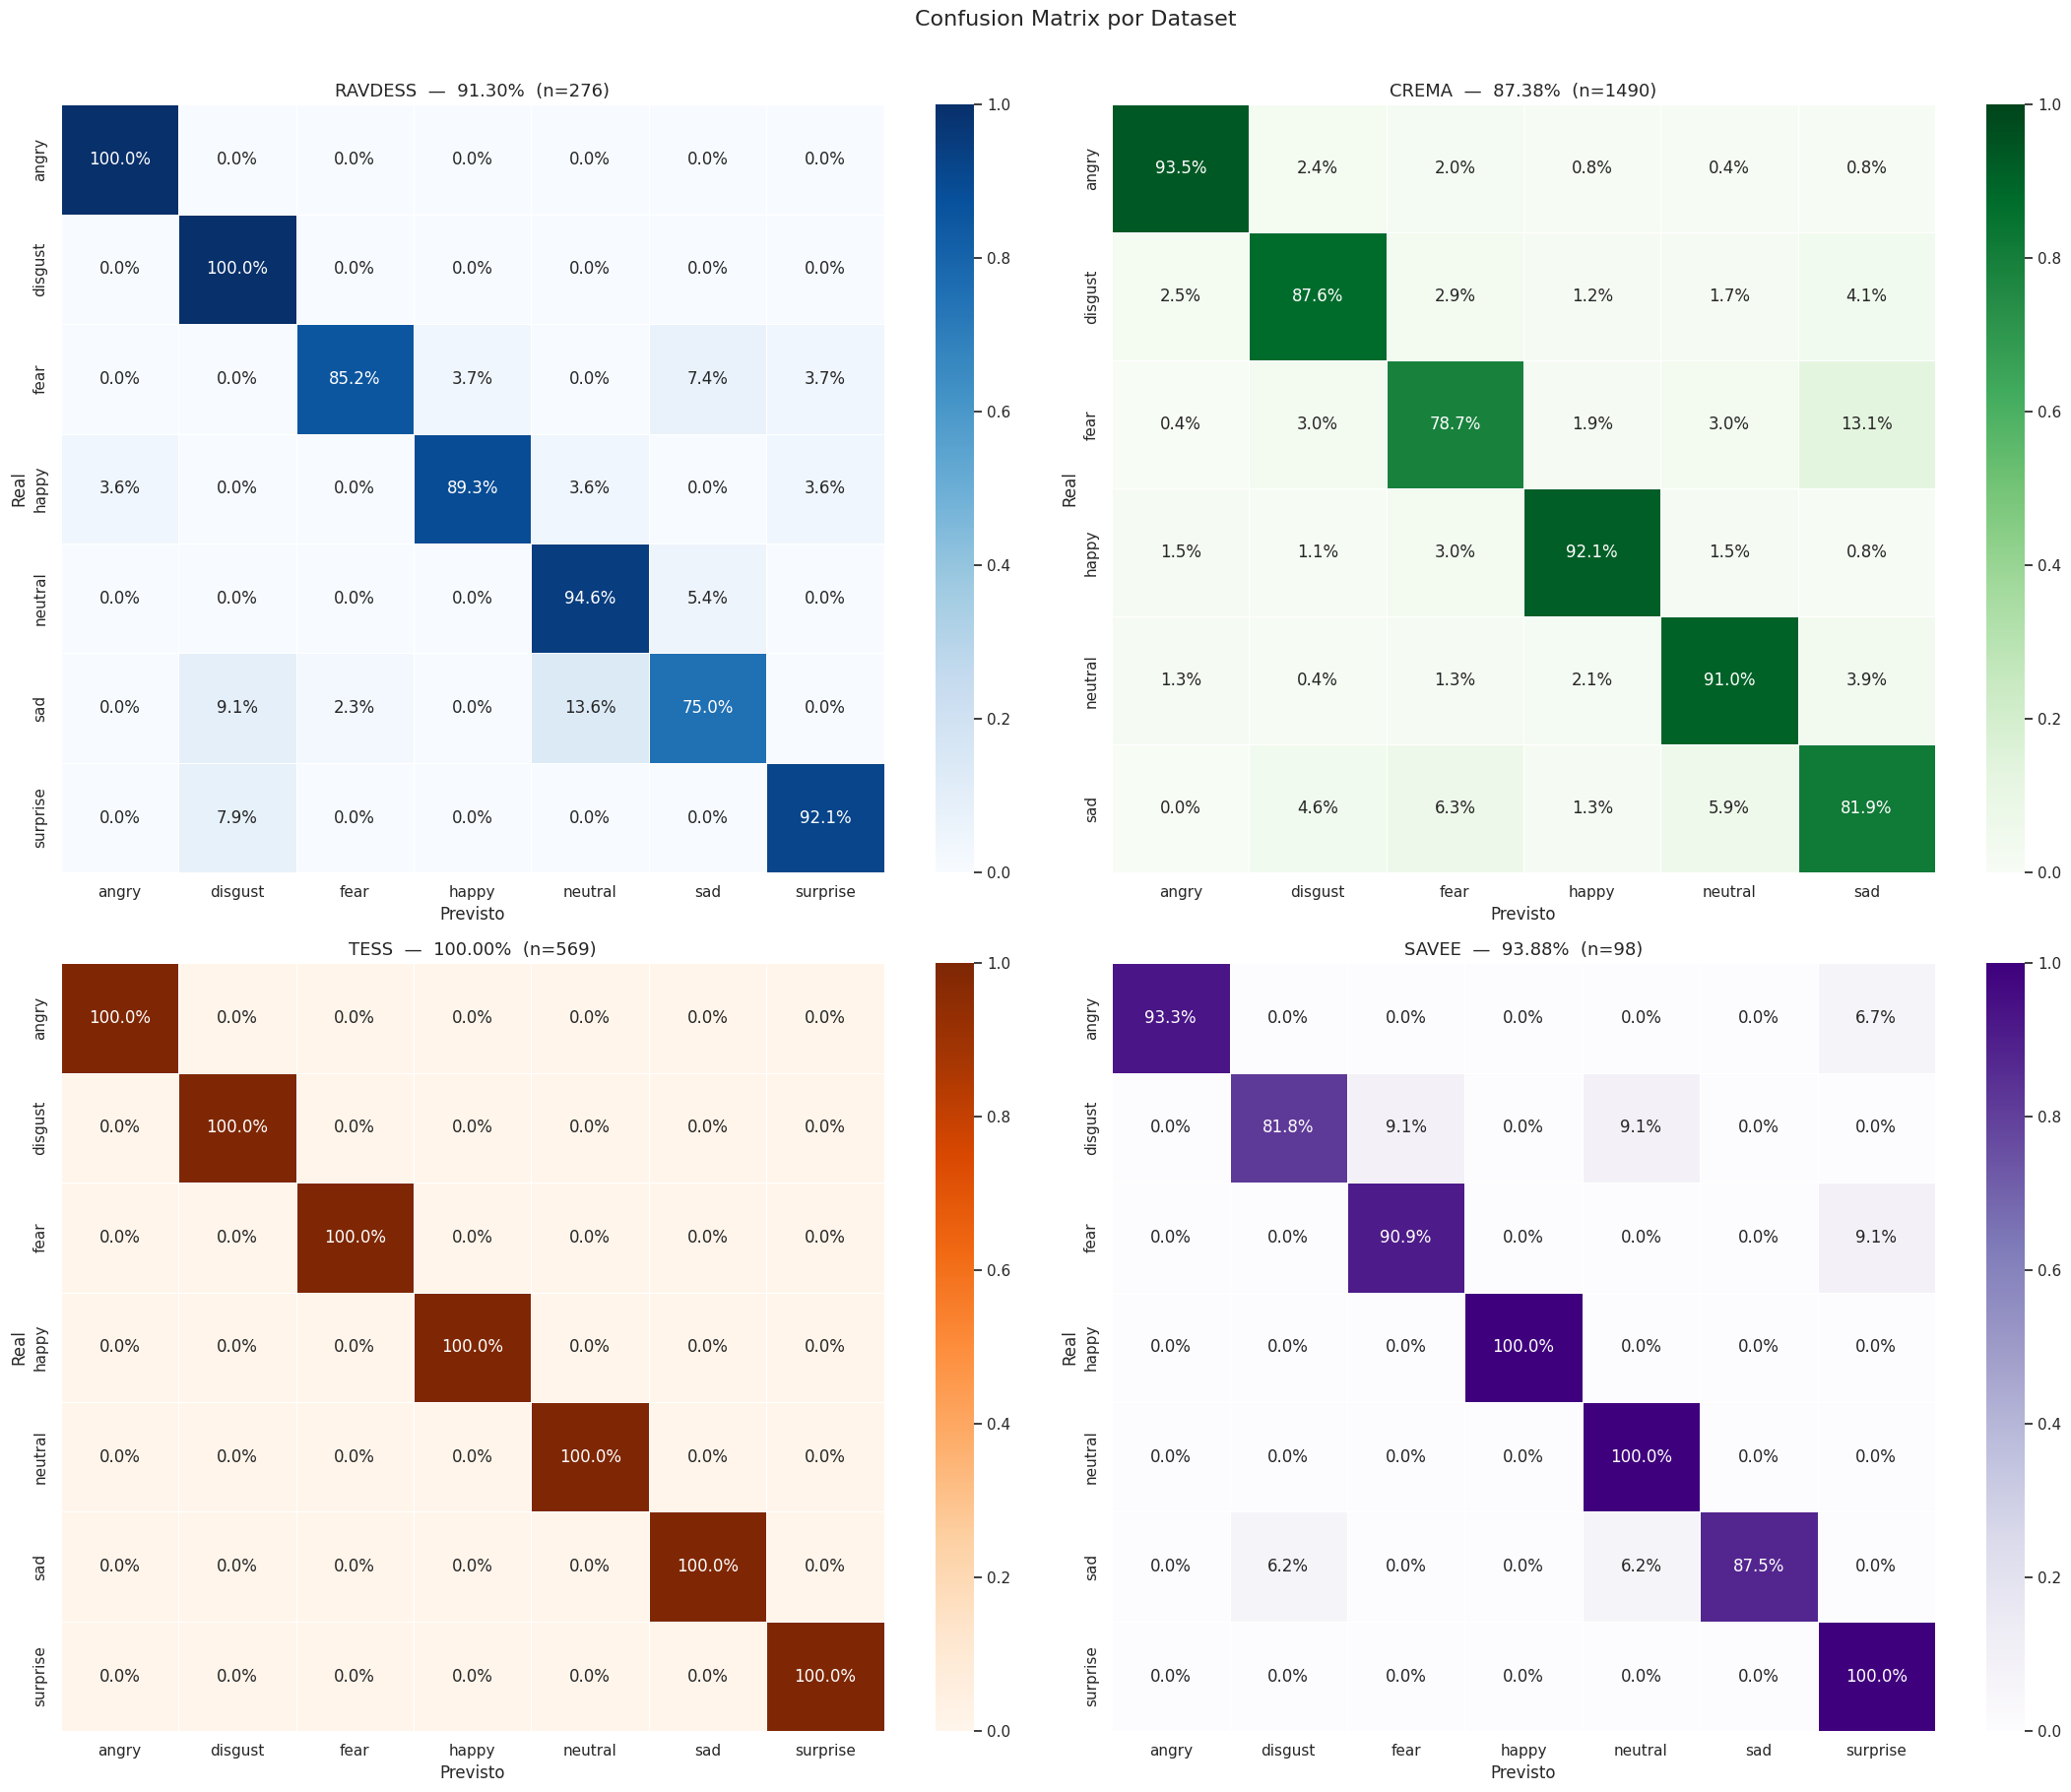

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

cmap_per_ds = {'RAVDESS': 'Blues', 'CREMA': 'Greens', 'TESS': 'Oranges', 'SAVEE': 'Purples'}

for ax, (ds, res) in zip(axes, ds_results.items()):
    emos = res['emos']
    cm   = confusion_matrix(res['t'], res['p'],
                            labels=res['emo_idx'], normalize='true')
    sns.heatmap(
        pd.DataFrame(cm, index=emos, columns=emos),
        annot=True, fmt='.1%',
        cmap=cmap_per_ds.get(ds, 'Blues'),
        linewidths=0.5, ax=ax,
        vmin=0, vmax=1
    )
    ax.set_title(f'{ds}  —  {res["acc"]*100:.2f}%  (n={res["n"]})', size=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrix per Dataset', size=16, y=1.01)
plt.tight_layout()
plt.show()

### 11.2 Recall Heatmap (Emotion x Dataset)

A heatmap showing recall for each emotion across all four datasets. Gray cells marked "N/A" indicate emotions not present in that dataset.

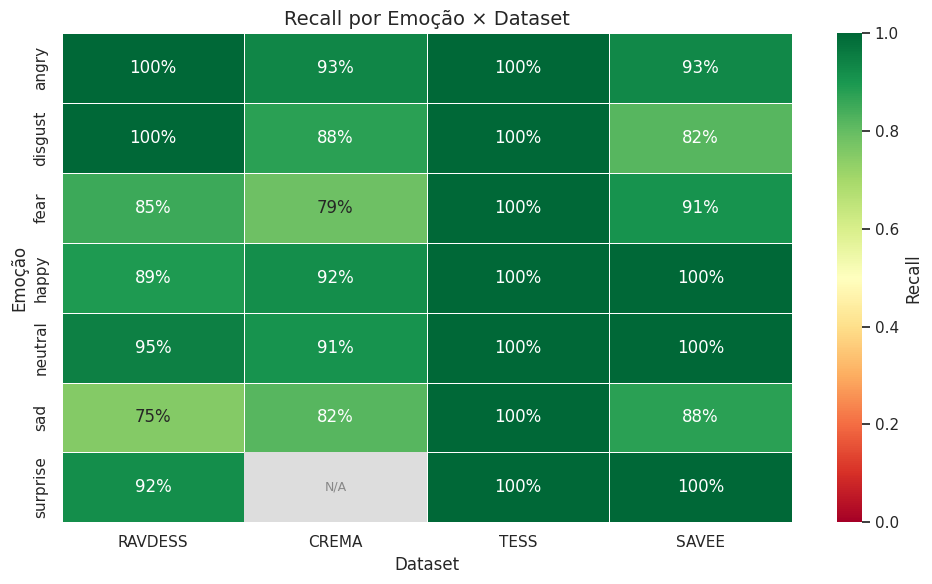


NaN = emoção não presente neste dataset


In [22]:
recall_matrix = pd.DataFrame(index=ALL_EMOTIONS, columns=DATASETS, dtype=float)

for ds, res in ds_results.items():
    for i, emo in enumerate(ALL_EMOTIONS):
        mask_emo = (res['t'] == i)
        if mask_emo.sum() == 0:
            recall_matrix.loc[emo, ds] = np.nan  # emoção ausente neste dataset
        else:
            recall_matrix.loc[emo, ds] = (res['p'][mask_emo] == i).mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    recall_matrix.astype(float),
    annot=True, fmt='.0%',
    cmap='RdYlGn',
    linewidths=0.5, ax=ax,
    vmin=0, vmax=1,
    mask=recall_matrix.isna(),   # cinza para emoções ausentes
    cbar_kws={'label': 'Recall'}
)
for i, emo in enumerate(ALL_EMOTIONS):
    for j, ds in enumerate(DATASETS):
        if pd.isna(recall_matrix.loc[emo, ds]):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                                        color='#dddddd', lw=0))
            ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                    fontsize=9, color='#888888')

ax.set_title('Recall per Emotion x Dataset', size=14)
ax.set_xlabel('Dataset')
ax.set_ylabel('Emoção')
plt.tight_layout()
plt.show()

print('\nNaN = emotion not present in this dataset')

### 11.3 Accuracy Bar Chart & Learning Curves

Left panel: per-dataset accuracy compared to the global average and the 90% target.
Right panel: training and validation accuracy curves over epochs.

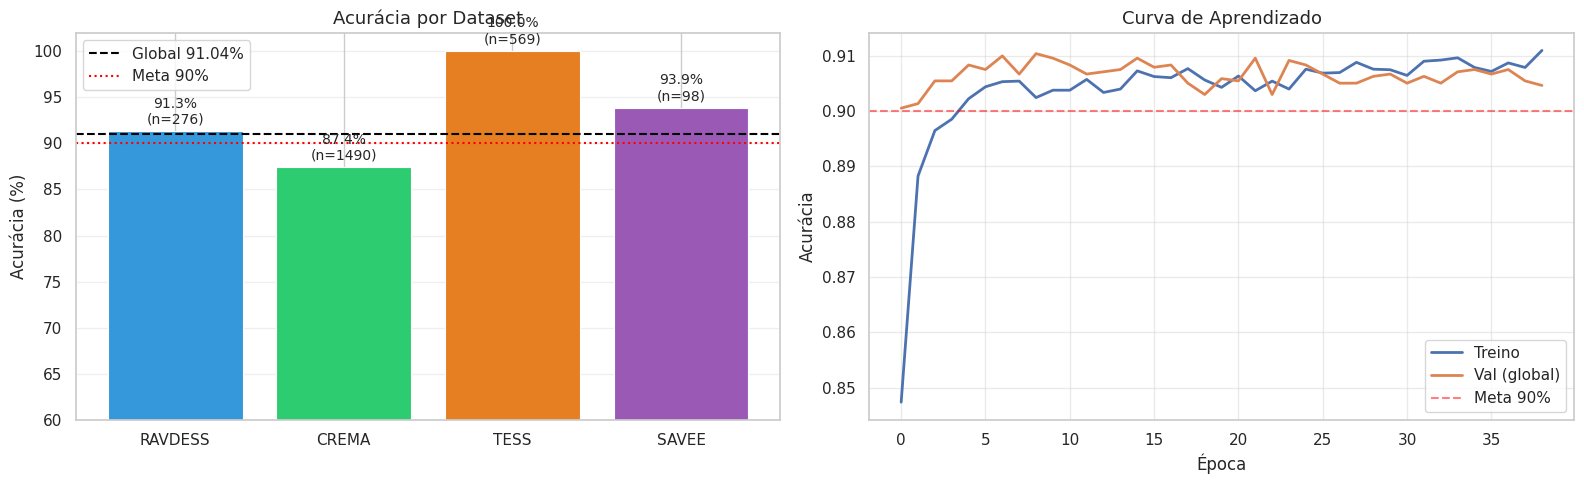

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ds_names = list(ds_results.keys())
ds_accs  = [ds_results[ds]['acc'] * 100 for ds in ds_names]
ds_ns    = [ds_results[ds]['n']         for ds in ds_names]
colors   = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

bars = axes[0].bar(ds_names, ds_accs, color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(y=acc_global * 100, color='black', ls='--', lw=1.5,
                label=f'Global {acc_global*100:.2f}%')
axes[0].axhline(y=90, color='red', ls=':', lw=1.5, label='Target 90%')
axes[0].set_ylim(60, 102)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy per Dataset', size=13)
axes[0].legend()
for bar, acc_v, n in zip(bars, ds_accs, ds_ns):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc_v:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(history['train_acc'], label='Treino', lw=2)
axes[1].plot(history['val_acc'],   label='Val (global)', lw=2)
axes[1].axhline(y=0.9, color='red', ls='--', alpha=0.5, label='Target 90%')
axes[1].set_title('Learning Curves', size=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### 11.4 Grouped Recall Bar Chart (Emotion x Dataset)

Recall for each emotion, grouped by dataset. This view makes it easy to spot which emotions are hardest to classify in each dataset.

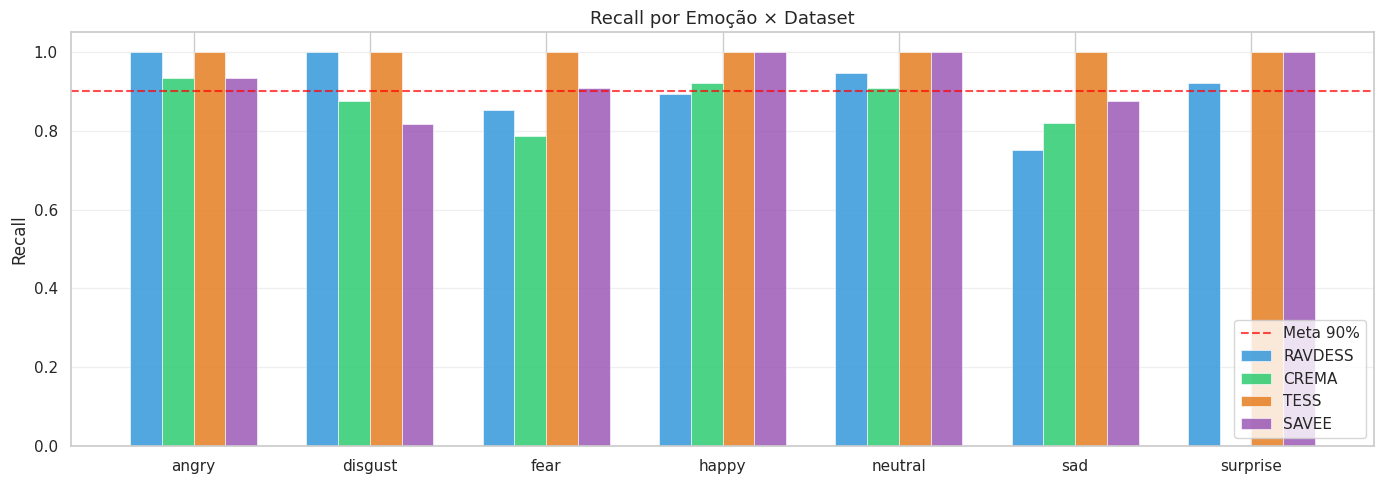

In [24]:
recall_df = recall_matrix.copy().astype(float)

fig, ax = plt.subplots(figsize=(14, 5))
x        = np.arange(len(ALL_EMOTIONS))
width    = 0.18
offsets  = np.linspace(-1.5 * width, 1.5 * width, len(DATASETS))

for offset, ds, color in zip(offsets, DATASETS, colors):
    vals = [recall_df.loc[emo, ds] if not np.isnan(recall_df.loc[emo, ds]) else 0
            for emo in ALL_EMOTIONS]
    bars = ax.bar(x + offset, vals, width, label=ds, color=color,
                  alpha=0.85, edgecolor='white', linewidth=0.5)

ax.axhline(y=0.9, color='red', ls='--', lw=1.5, alpha=0.7, label='Target 90%')
ax.set_xticks(x)
ax.set_xticklabels(ALL_EMOTIONS)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Recall')
ax.set_title('Recall per Emotion x Dataset', size=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 12. Save Model Artifacts

Save the trained model and preprocessing objects for later inference:

- **Model checkpoint** (`SER_emotion2vec_v15.pt`): Contains the MLP state dict, validation accuracy, class definitions, input dimensions, backbone name, and per-dataset accuracy.
- **Scaler** (`scaler_v15.pkl`): The fitted StandardScaler needed to normalize new inputs at inference time.

In [ ]:
import pickle
save_dir = os.path.join(os.getcwd(), 'saved_models')
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'model_state_dict': mlp.state_dict(),
    'val_accuracy':     best_val_acc,
    'emo_classes':      ALL_EMOTIONS,
    'gen_classes':      ALL_GENDERS,
    'in_dim':           in_dim,
    'backbone':         'iic/emotion2vec_plus_large',
    'per_dataset_acc':  {ds: ds_results[ds]['acc'] for ds in ds_results},
}, os.path.join(save_dir, 'SER_emotion2vec_v15.pt'))

with open(os.path.join(save_dir, 'scaler_v15.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print('Model saved to saved_models/SER_emotion2vec_v15.pt')
print(f'Global val accuracy: {best_val_acc*100:.2f}%')
print('Accuracy per dataset:')
for ds, res in ds_results.items():
    print(f'  {ds}: {res["acc"]*100:.2f}%')